# REM-P2: nutritional status among children enrolled in care

**Preliminary exploration of candidate 7 · 2020–2024**  
**Workshop:** W1 — *Discovering questions worth investigating*  
**Notebook purpose:** turn the idea into a researchable question, inspect the available datasets and dictionaries, run initial quality checks, and produce a reproducible first description.

> **Scope:** this exploration covers administrative counts of children recorded in REM-P2 care. It does not estimate population prevalence, track individuals between reporting cuts, or support causal inference.

**Brief and rubric:** [W1_IIB423T-1_Brief_and_Rubric_Tomas_Fontecilla.pdf](../W1_IIB423T-1_Brief_and_Rubric_Tomas_Fontecilla.pdf). This notebook develops candidate 7. If the team's W1 submission must compare two alternatives, the documented comparison with the other candidate still needs to be added; it is not addressed here.


## 1. Business framing in the workshop's seven steps

| Step | Initial proposal for REM-P2 |
|---|---|
| 1. Decision | Propose a monitoring view that helps the child health team identify variation in recorded nutritional counts and prioritize data review or management questions. |
| 2. Success criterion | Confirm codes and age groups against each year's dictionary; quantify matched-record coverage; present comparable reporting cuts with caveats; produce at least one interpretable, reproducible visualization. |
| 3. Business question | Among children recorded in care in REM-P2, how does the share of counts for P2070503 (overweight/risk of obesity) and P2070504 (obese) relative to P2060000 Col01 (both sexes) vary between June and December 2020–2024, and what age/sex patterns appear in the disaggregated fields that are reported? |
| 4. Process | Child health check-up and REM-P2 recording of the population in care/nutritional status at reported cuts. |
| 5. Entity, event, and state | The dataset contains aggregate counts by service, facility, reporting month (Mes), and service code. It has no person-level rows. A child could be counted again in another cut. |
| 6. Representation | One row per reported combination of year, reporting month, service, facility, and code; Col01 is the total for both sexes and Col04–Col31 detail age/sex for the age bands on sheet P2. Age fields may be blank and will be audited before use. |
| 7. Measurement | Main metric: Col01 for P2070503 + P2070504 divided by Col01 for P2060000, limited to facility-cut units with a denominator and both observed codes. The age/sex breakdown is secondary and is reported with field-availability coverage. Both measures are **shares of counts recorded in care**, never child prevalence. |

**Potential use:** monitor the distribution of records by age/sex, compare reporting cuts, and detect reporting issues. Chile's Ministry of Health (MINSAL) has a 2023–2030 national strategy on overweight and obesity in childhood and adolescence. It provides relevant context but does not turn this administrative indicator into a population estimate: [MINSAL Strategy 2023–2030](https://www.minsal.cl/lanzamiento-estrategia-para-detener-la-aceleracion-del-sobrepeso-y-obesidad-en-la-ninez-y-adolescencia-2023-2030/).


## 2. Available sources and initial inspection

The project inventory indicates that REM files and dictionaries should be checked year by year because codes, columns, or sections may change. This notebook reads **one Serie P ZIP per year (2020–2024)** directly, without extracting or modifying the originals. The already-extracted 2024 CSV/TXT copy is not counted again.

Local reference files:

- Inventory and provenance: FUENTES.csv and README.md in the project root.
- Data: REM/2020/SERIE_REM_2020.zip through REM/2024/SERIE_REM_2024.zip.
- Dictionaries: each ZIP contains the annual Serie P codebook, sheet P2.
- DEIS open-data reference: [deis.minsal.cl](https://deis.minsal.cl/#datosabiertos).

### Findings from the first scan (preliminary calculation)

| Year | Rows in the full Serie P | Rows for relevant P2 codes | Months found for these codes | Raw P2060000 rows by cut (before deduplication) |
|---|---:|---:|---|---|
| 2020 | 455,729 | 9,944 | June and December | June: 83; December: 1,950 |
| 2021 | 890,014 | 19,088 | June and December | June: 1,964; December: 1,982 |
| 2022 | 993,701 | 19,787 | June and December | June: 1,993; December: 2,010 |
| 2023 | 1,117,209 | 20,539 | June and December | June: 1,992; December: 2,002 |
| 2024 | 1,200,514 | 20,843 | June and December | June: 2,014; December: 2,019 |

Recorded coverage in June 2020 needs investigation: P2060000 sums to 51,788 in Col01, compared with 545,388–609,364 in June 2021–2024, and only 83 facility-service records have a denominator. This difference is not attributed to a cause without documentary confirmation. Age/sex fields (Col04–Col31) also contain frequent blanks; therefore Col01 is the main metric, while the age profile will be reported with its availability, without implicitly treating blanks as zero. In June 2024, only 713 of the 1,764 matched units have all 26 age/sex cells complete for the denominator and both categories; in December the figure is 727 of 1,762. In December 2021, 18 rows were found across 9 duplicate keys at two facilities; their values are identical in the analyzed columns, so the routine removes the exact copies and records the check.

The five dictionaries retain the codes for the population in care, categories P2070501–P2070506, and the age bands in Col04–Col31. Code P2501800 (no nutritional assessment due to life-course category or special condition) appears from 2023 onward. A reconciliation that includes it is therefore shown only for 2023–2024 and requires confirmation against the applicable manual for those years.

The first calculation of the main metric (Col01, both sexes), using facility-service-cut records that report the denominator and both target codes, produced the following values. The summary cell reproduces the figures; December 2021 is calculated after exact copies are removed:

| Year | June | December |
|---|---:|---:|
| 2020 | 33.61%* | 35.05% |
| 2021 | 35.46% | 37.53% |
| 2022 | 36.59% | 35.46% |
| 2023 | 34.59% | 34.76% |
| 2024 | 35.16% | 34.72% |

* June 2020 has much lower facility coverage. It should not be interpreted as a nationally comparable cut until coverage is clarified. These percentages summarize matched records; they are neither prevalence estimates nor changes in individual children. Age/sex fields have frequent blanks, so they will be analyzed separately with a coverage table and a sensitivity calculation that treats blanks as zero—not as a confirmed decision. The following cells reproduce the scan and show how the figures are built.


## 3. Environment setup

Analysis dependencies: pandas, numpy, and openpyxl. Jupyter provides IPython for displaying the SVG chart generated later. If the selected kernel does not have these packages, activate the course environment or install the dependencies in that environment before running the notebook. No package installation is needed to read the CSV/TXT files inside the ZIP archives.


In [1]:
from pathlib import Path
from zipfile import ZipFile
from io import BytesIO
import pandas as pd
import numpy as np
from openpyxl import load_workbook

# Find the project root whether Jupyter starts in the project folder or in REM/.
_candidatos = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (p for p in _candidatos if (p / "REM" / "2020").is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cannot find REM/2020. Open the notebook from the project folder "
        "or one of its subfolders."
    )
REM_DIR = PROJECT_ROOT / "REM"

P2_CODES = {"P2060000", *(f"P20705{i:02d}" for i in range(1, 7)), "P2501800"}
KEY_FIELDS = ["Mes", "IdServicio", "IdEstablecimiento", "CodigoPrestacion"]
UNIT_FIELDS = ["AnioFuente", "Mes", "IdServicio", "IdEstablecimiento"]
NUMERIC_FIELDS = [f"Col{i:02d}" for i in range(1, 32)]
AGE_SEX_MAP = [
    ("1 month", "Male", "Col06"), ("1 month", "Female", "Col07"),
    ("2 months", "Male", "Col08"), ("2 months", "Female", "Col09"),
    ("3 months", "Male", "Col10"), ("3 months", "Female", "Col11"),
    ("4 months", "Male", "Col12"), ("4 months", "Female", "Col13"),
    ("5 months", "Male", "Col14"), ("5 months", "Female", "Col15"),
    ("6 months", "Male", "Col16"), ("6 months", "Female", "Col17"),
    ("7–11 months", "Male", "Col18"), ("7–11 months", "Female", "Col19"),
    ("12–17 months", "Male", "Col20"), ("12–17 months", "Female", "Col21"),
    ("18–23 months", "Male", "Col22"), ("18–23 months", "Female", "Col23"),
    ("24–35 months", "Male", "Col24"), ("24–35 months", "Female", "Col25"),
    ("36–41 months", "Male", "Col26"), ("36–41 months", "Female", "Col27"),
    ("42–47 months", "Male", "Col28"), ("42–47 months", "Female", "Col29"),
    ("48–59 months", "Male", "Col30"), ("48–59 months", "Female", "Col31"),
]
AGE_FIELDS_1_59 = [col for _, _, col in AGE_SEX_MAP]
print("Project root:", PROJECT_ROOT)
print("pandas:", pd.__version__)


Project root: /home/presi-sh/Documents/UDD/Trimestre11/Business-Intelligence/Workshops/Workshop1
pandas: 2.2.3


## 4. Reproducibly load the five ZIP archives

The notebook reads the files in chunks and retains only the required P2 codes and columns Col01–Col31. Identifiers remain text to avoid code conversions. It records the number of rows in the full Serie P file and in the selected P2 rows.


In [2]:
def localizar_miembros(zip_obj):
    miembros = [n for n in zip_obj.namelist() if not n.endswith("/")]
    datos = [n for n in miembros if Path(n).name.lower().startswith("seriep")
             and Path(n).suffix.lower() in {".txt", ".csv"}]
    diccionarios = [n for n in miembros if "sp_" in Path(n).name.lower()
                    and Path(n).suffix.lower() in {".xlsm", ".xlsx"}]
    if len(datos) != 1:
        raise ValueError(f"Expected exactly one SerieP file; found {datos}")
    if len(diccionarios) != 1:
        raise ValueError(f"Expected an SP dictionary; found {diccionarios}")
    return datos[0], diccionarios[0]

zip_por_anio = {}
for carpeta in sorted(REM_DIR.iterdir()):
    if carpeta.is_dir() and carpeta.name.isdigit():
        zips = sorted(carpeta.glob("*.zip"))
        if zips:
            zip_por_anio[int(carpeta.name)] = zips[0]

anios_esperados = set(range(2020, 2025))
if set(zip_por_anio) != anios_esperados:
    raise FileNotFoundError(
        f"Expected REM ZIP files for {sorted(anios_esperados)}; found {sorted(zip_por_anio)}"
    )

partes_p2 = []
filas_fuente = []
columnas_datos = ["Mes", "IdServicio", "IdEstablecimiento", "CodigoPrestacion"] + NUMERIC_FIELDS

for anio, ruta_zip in sorted(zip_por_anio.items()):
    with ZipFile(ruta_zip) as zf:
        miembro_datos, miembro_diccionario = localizar_miembros(zf)
        with zf.open(miembro_datos) as f:
            encabezado = pd.read_csv(f, sep=";", nrows=0, encoding="utf-8-sig")
        faltantes = set(columnas_datos) - set(encabezado.columns)
        if faltantes:
            raise ValueError(f"{anio}: required columns are missing: {sorted(faltantes)}")

        n_total = 0
        n_p2 = 0
        meses = set()
        partes_anio = []
        with zf.open(miembro_datos) as f:
            for bloque in pd.read_csv(
                f,
                sep=";",
                usecols=columnas_datos,
                dtype={
                    "IdServicio": "string",
                    "IdEstablecimiento": "string",
                    "CodigoPrestacion": "string",
                },
                chunksize=200_000,
                low_memory=False,
                encoding="utf-8-sig",
            ):
                n_total += len(bloque)
                bloque["Mes"] = pd.to_numeric(bloque["Mes"], errors="coerce").astype("Int64")
                bloque["CodigoPrestacion"] = bloque["CodigoPrestacion"].str.strip()
                seleccionado = bloque.loc[bloque["CodigoPrestacion"].isin(P2_CODES)].copy()
                if not seleccionado.empty:
                    n_p2 += len(seleccionado)
                    meses.update(seleccionado["Mes"].dropna().astype(int).tolist())
                    seleccionado["AnioFuente"] = anio
                    partes_anio.append(seleccionado)
        if partes_anio:
            partes_p2.extend(partes_anio)
        filas_fuente.append({
            "Year": anio,
            "ZIP": str(ruta_zip.relative_to(PROJECT_ROOT)),
            "File inside ZIP": miembro_datos,
            "Dictionary inside ZIP": miembro_diccionario,
            "Full Serie P rows": n_total,
            "Selected P2 rows": n_p2,
            "Months found for selected codes": ", ".join(map(str, sorted(meses))),
        })

datos_p2 = pd.concat(partes_p2, ignore_index=True)
for col in NUMERIC_FIELDS:
    datos_p2[col] = pd.to_numeric(datos_p2[col], errors="coerce")

inventario = pd.DataFrame(filas_fuente).sort_values("Year").reset_index(drop=True)
display(inventario)
print(f"Selected P2 rows loaded: {len(datos_p2):,}")


Selected P2 rows loaded: 90,201


,Year,ZIP,File inside ZIP,Dictionary inside ZIP,Full Serie P rows,Selected P2 rows,Months found for selected codes
0,2020,REM/2020/SERIE_REM_2020.zip,SerieP_2020.txt,DICCIONARIOS/SP_20_V1.0 CODIGOS.xlsm,455729,9944,"6, 12"
1,2021,REM/2021/SERIE_REM_2021.zip,2021/SerieP_2021.txt,2021/DICCIONARIOS/SP_21_V1.1 CODIGOS.xlsm,890014,19088,"6, 12"
2,2022,REM/2022/SERIE_REM_2022.zip,SerieP.txt,DICCIONARIOS/SP_22_V1.0 CODIGOS.xlsm,993701,19787,"6, 12"
3,2023,REM/2023/SERIE_REM_2023.zip,Datos/SerieP2023.txt,Diccionarios/DICCIONARIO CODIGOS SP_23_V1.2.xlsm,1117209,20539,"6, 12"
4,2024,REM/2024/SERIE_REM_2024.zip,Datos/SerieP2024.csv,Diccionarios/DICCIONARIO CODIGOS SP_24_V1.1.xlsm,1200514,20843,"6, 12"


## 5. Check codes and labels against each annual dictionary

Labels are not carried forward from a single year: this cell reads sheet P2 from the annual dictionary included in each ZIP. It also flags any code or label changes before comparing years.


In [3]:
CODIGOS_A_REVISAR = ["P2060000", "P2070501", "P2070502", "P2070503",
                       "P2070504", "P2070505", "P2070506", "P2501800"]
filas_diccionario = []

for anio, ruta_zip in sorted(zip_por_anio.items()):
    with ZipFile(ruta_zip) as zf:
        _, miembro_diccionario = localizar_miembros(zf)
        wb = load_workbook(BytesIO(zf.read(miembro_diccionario)), read_only=True, data_only=True)
        ws = wb["P2"]
        encontrados = set()
        for row in ws.iter_rows(values_only=True):
            codigo = str(row[0]).strip() if row and row[0] is not None else ""
            if codigo in CODIGOS_A_REVISAR:
                partes = [" ".join(str(x).strip().split()) for x in row[1:3] if x is not None and str(x).strip()]
                filas_diccionario.append({"Year": anio, "Code": codigo,
                                          "Dictionary label": " — ".join(partes)})
                encontrados.add(codigo)
        wb.close()

diccionario_p2 = pd.DataFrame(filas_diccionario)
display(diccionario_p2.sort_values(["Code", "Year"]))

,Year,Code,Dictionary label
0,2020,P2060000,TOTAL DE NIÑOS EN CONTROL
7,2021,P2060000,TOTAL DE NIÑOS EN CONTROL
14,2022,P2060000,TOTAL DE NIÑOS EN CONTROL
21,2023,P2060000,TOTAL DE NIÑOS/AS EN CONTROL
29,2024,P2060000,TOTAL DE NIÑOS/AS EN CONTROL
1,2020,P2070501,DIAGNOSTICO NUTRICIONAL INTEGRADO — RIESGO DE ...
8,2021,P2070501,DIAGNOSTICO NUTRICIONAL INTEGRADO — RIESGO DE ...
15,2022,P2070501,DIAGNOSTICO NUTRICIONAL INTEGRADO — RIESGO DE ...
22,2023,P2070501,DIAGNOSTICO NUTRICIONAL INTEGRADO — RIESGO DE ...
30,2024,P2070501,DIAGNOSTICO NUTRICIONAL INTEGRADO — RIESGO DE ...


### Age and sex column map

The 2020–2024 P2 dictionaries retain the same table map: Col04–Col05 = under 1 month; Col06–Col31 = ages 1 to 59 months, by age band and sex. The main metric uses Col01 (both-sex total) and includes the full population recorded on form P2. The breakdown for ages 1–59 months is secondary: it calculates the availability of each age/sex cell and provides a sensitivity calculation for blanks. Do not add Col01 across the five years as if these were unique children.


In [4]:
mapa_edad = pd.DataFrame(AGE_SEX_MAP, columns=["Age group", "Sex", "Column"])
display(mapa_edad)


,Age group,Sex,Column
0,1 month,Male,Col06
1,1 month,Female,Col07
2,2 months,Male,Col08
3,2 months,Female,Col09
4,3 months,Male,Col10
5,3 months,Female,Col11
6,4 months,Male,Col12
7,4 months,Female,Col13
8,5 months,Male,Col14
9,5 months,Female,Col15


## 6. Initial data quality checks (check families to map to the course Five Cs)

The brief asks for the **Five Cs**. To avoid inventing the exact terms used in Class 03, this notebook lists observable checks; the team should map them to the course terms before submission:

- **Coverage/completeness:** years, reporting cuts, records by code, key fields, and the share of the denominator retained when matching codes.
- **Consistency:** Col01 against Col02 + Col03 and against the sum of age groups when the fields are complete.
- **Conformance/validity:** codes present in that year's dictionary; negative or non-numeric values.
- **Uniqueness:** key year + month + service + facility + code; exact copies are deduplicated in memory and reported. Duplicates with differing values are excluded and listed.
- **Comparability and timeliness:** same codes/labels and age bands across years; reporting cuts actually available; special limitation for June 2020; file package date/version.

These are descriptive names for the checks; they do not replace the course's exact terminology.


In [5]:
# Consistency checks for relevant codes. Blank age fields
# are counted as missing; they are not converted to zero here.
comparables = datos_p2.copy()
sex_cols = ["Col02", "Col03"]
age_cols_all = [f"Col{i:02d}" for i in range(4, 32)]
filas_calidad = []

for (anio, codigo), g in comparables.groupby(["AnioFuente", "CodigoPrestacion"], dropna=False):
    clave_completa = g[["Mes", "IdServicio", "IdEstablecimiento", "CodigoPrestacion"]].notna().all(axis=1)
    sex_completo = g[["Col01", *sex_cols]].notna().all(axis=1)
    suma_edades_observadas = g[age_cols_all].sum(axis=1, min_count=1)
    total_y_edad_observada = g["Col01"].notna() & suma_edades_observadas.notna()
    filas_calidad.append({
        "Year": int(anio),
        "Code": codigo,
        "Rows": len(g),
        "Incomplete keys": int((~clave_completa).sum()),
        "Missing Col01": int(g["Col01"].isna().sum()),
        "Negative cells in Col01–Col31": int((g[NUMERIC_FIELDS] < 0).sum().sum()),
        "Rows with any blank in Col04–Col31": int(g[age_cols_all].isna().any(axis=1).sum()),
        "Col01≠Col02+Col03 (complete fields)": int(
            (((g["Col01"] - g["Col02"] - g["Col03"]).abs() > 0.001)
             .where(sex_completo, False)).sum()
        ),
        "Col01≠sum of reported age cells": int(
            (((g["Col01"] - suma_edades_observadas).abs() > 0.001)
             .where(total_y_edad_observada, False)).sum()
        ),
    })

calidad_inicial = pd.DataFrame(filas_calidad).sort_values(["Year", "Code"])
display(calidad_inicial)


,Year,Code,Rows,Incomplete keys,Missing Col01,Negative cells in Col01–Col31,Rows with any blank in Col04–Col31,Col01≠Col02+Col03 (complete fields),Col01≠sum of reported age cells
0,2020,P2060000,2033,0,0,0,1311,0,1
1,2020,P2070501,1303,0,0,0,1303,0,0
2,2020,P2070502,732,0,0,0,732,0,0
3,2020,P2070503,1914,0,0,0,1914,0,0
4,2020,P2070504,1853,0,0,0,1853,0,0
5,2020,P2070505,1988,0,0,0,1988,0,0
6,2020,P2070506,121,0,0,0,121,0,0
7,2021,P2060000,3946,0,0,0,2417,0,5
8,2021,P2070501,2462,0,0,0,2462,0,0
9,2021,P2070502,1375,0,0,0,1375,0,0


## 7. Duplicates: log, analytical deduplication, and conflicts

Deduplication is applied in memory only and only to rows identical on the key and columns analyzed in this exploration. The original files are not modified. If a key has more than one distinct version, the entire affected facility-cut unit is excluded to avoid summing ambiguous rows.


In [6]:
CLAVE_CODIGO = UNIT_FIELDS + ["CodigoPrestacion"]
n_unidades_con_clave_incompleta = int(datos_p2[UNIT_FIELDS].isna().any(axis=1).sum())
datos_con_claves = datos_p2.loc[datos_p2[UNIT_FIELDS].notna().all(axis=1)].copy()
conteo_claves = (datos_con_claves.groupby(CLAVE_CODIGO, dropna=False)
                 .size().rename("row_count").reset_index())
duplicados_clave = conteo_claves.loc[conteo_claves["row_count"] > 1].copy()

columnas_identidad_analitica = CLAVE_CODIGO + NUMERIC_FIELDS
n_copias_exactas_eliminadas = int(
    datos_con_claves.duplicated(subset=columnas_identidad_analitica, keep="first").sum()
)
datos_sin_copias = datos_con_claves.drop_duplicates(
    subset=columnas_identidad_analitica, keep="first"
).copy()

claves_aun_duplicadas = (datos_sin_copias.groupby(CLAVE_CODIGO, dropna=False)
                         .size().loc[lambda s: s > 1].reset_index(name="version_count"))
if len(claves_aun_duplicadas):
    conflicto_unidades = claves_aun_duplicadas[UNIT_FIELDS].drop_duplicates()
    _idx = pd.MultiIndex.from_frame(conflicto_unidades)
    _idx_datos = pd.MultiIndex.from_frame(datos_sin_copias[UNIT_FIELDS])
    datos_limpios = datos_sin_copias.loc[~_idx_datos.isin(_idx)].copy()
else:
    conflicto_unidades = pd.DataFrame(columns=UNIT_FIELDS)
    datos_limpios = datos_sin_copias.copy()

display(duplicados_clave.sort_values(CLAVE_CODIGO))
print("Rows excluded for incomplete key:", n_unidades_con_clave_incompleta)
print("Exact duplicate rows removed from analysis:", n_copias_exactas_eliminadas)
print("Facility-cut units excluded due to conflicts:", len(conflicto_unidades))


Rows excluded for incomplete key: 0
Exact duplicate rows removed from analysis: 9
Facility-cut units excluded due to conflicts: 0


,AnioFuente,Mes,IdServicio,IdEstablecimiento,CodigoPrestacion,row_count
19459,2021,12,1,101404,P2060000,2
19460,2021,12,1,101404,P2070501,2
19461,2021,12,1,101404,P2070503,2
19462,2021,12,1,101404,P2070505,2
19477,2021,12,1,101702,P2060000,2
19478,2021,12,1,101702,P2070501,2
19479,2021,12,1,101702,P2070503,2
19480,2021,12,1,101702,P2070504,2
19481,2021,12,1,101702,P2070505,2


## 8. Build a panel by facility and reporting cut

Rows are matched by year, month, service, and facility. The main measure uses only units with a denominator (P2060000) and observed rows for both codes P2070503 and P2070504. A missing row is not automatically converted to zero.


In [7]:
def tabla_codigo(codigo, campos):
    t = datos_limpios.loc[
        datos_limpios["CodigoPrestacion"].eq(codigo), UNIT_FIELDS + campos
    ].copy()
    t = t.set_index(UNIT_FIELDS)
    # Duplicate/conflicting keys were already removed above.
    t = t.rename(columns={c: f"{codigo}__{c}" for c in campos})
    return t

panel = tabla_codigo("P2060000", NUMERIC_FIELDS)
panel["tiene_P2060000"] = True
for codigo in ["P2070503", "P2070504", *[f"P20705{i:02d}" for i in (1,2,5,6)], "P2501800"]:
    t = tabla_codigo(codigo, NUMERIC_FIELDS)
    panel = panel.join(t, how="left")
    panel[f"tiene_{codigo}"] = panel.index.isin(t.index)

panel_filas = panel.reset_index()
campos_den_1_59 = [f"P2060000__{c}" for c in AGE_FIELDS_1_59]
campos_sobrepeso = [f"P2070503__{c}" for c in AGE_FIELDS_1_59]
campos_obesidad = [f"P2070504__{c}" for c in AGE_FIELDS_1_59]
campos_tres_codigos = ["P2060000__Col01", "P2070503__Col01", "P2070504__Col01"]


## 9. Main summary by reporting cut and sensitivity to missing codes

The main metric uses Col01 and units with a denominator and both target codes present. Two readings are shown: **complete**, which does not assume that a missing code row equals zero; and **missing code = zero (sensitivity)**, which fills zero only when the code row does not exist, while keeping a blank Col01 within an existing row as missing. Confirm the meaning of missing rows with DEIS before choosing a definitive reading.


In [8]:
resumen_cortes = []
for (anio, mes), g in panel_filas.groupby(["AnioFuente", "Mes"], dropna=False):
    den_col = g["P2060000__Col01"]
    den_ok = den_col.notna()
    n_den = int(den_ok.sum())
    total_den = float(den_col.loc[den_ok].sum())

    columnas_objetivo = ["P2070503__Col01", "P2070504__Col01"]
    campos_edad_tres_codigos = (
        [f"P2060000__{c}" for c in AGE_FIELDS_1_59]
        + [f"P2070503__{c}" for c in AGE_FIELDS_1_59]
        + [f"P2070504__{c}" for c in AGE_FIELDS_1_59]
    )
    filas_codigos = (
        den_ok & g["tiene_P2070503"] & g["tiene_P2070504"]
        & g[columnas_objetivo].notna().all(axis=1)
    )
    den_emparejado = float(den_col.loc[filas_codigos].sum())
    num_sobrepeso = float(g.loc[filas_codigos, "P2070503__Col01"].sum())
    num_obesidad = float(g.loc[filas_codigos, "P2070504__Col01"].sum())
    num_emparejado = num_sobrepeso + num_obesidad
    filas_edad_completa = filas_codigos & g[campos_edad_tres_codigos].notna().all(axis=1)

    # Sensitivity: a missing category row is treated as zero. A blank Col01
    # within an existing row remains missing.
    sobrepeso_cero = g["P2070503__Col01"].copy()
    obesidad_cero = g["P2070504__Col01"].copy()
    sobrepeso_cero.loc[~g["tiene_P2070503"]] = 0
    obesidad_cero.loc[~g["tiene_P2070504"]] = 0
    valido_cero = den_ok & sobrepeso_cero.notna() & obesidad_cero.notna()
    den_cero = float(den_col.loc[valido_cero].sum())
    num_cero = float(sobrepeso_cero.loc[valido_cero].sum() + obesidad_cero.loc[valido_cero].sum())

    resumen_cortes.append({
        "Year": int(anio),
        "Reporting month": int(mes),
        "Facility-service units with P2060000": n_den,
        "Units with P206 and both categories": int(filas_codigos.sum()),
        "Units with all 26 age/sex fields complete": int(filas_edad_completa.sum()),
        "Matched units covered (%)": 100 * filas_codigos.sum() / n_den if n_den else np.nan,
        "P2060000 Col01": total_den,
        "Matched P2060000 Col01": den_emparejado,
        "Col01 denominator coverage (%)": 100 * den_emparejado / total_den if total_den else np.nan,
        "Matched P2070503 Col01": num_sobrepeso,
        "Matched P2070504 Col01": num_obesidad,
        "Matched combined numerator": num_emparejado,
        "Matched share (%)": 100 * num_emparejado / den_emparejado if den_emparejado else np.nan,
        "Share with missing code=0 (%)": 100 * num_cero / den_cero if den_cero else np.nan,
    })

resumen_cortes = pd.DataFrame(resumen_cortes).sort_values(["Year", "Reporting month"]).reset_index(drop=True)
display(resumen_cortes.round(2))


,Year,Reporting month,Facility-service units with P2060000,Units with P206 and both categories,Units with all 26 age/sex fields complete,Matched units covered (%),P2060000 Col01,Matched P2060000 Col01,Col01 denominator coverage (%),Matched P2070503 Col01,Matched P2070504 Col01,Matched combined numerator,Matched share (%),Share with missing code=0 (%)
0,2020,6,83,71,26,85.54,51788.0,51673.0,99.78,12018.0,5350.0,17368.0,33.61,33.56
1,2020,12,1950,1724,461,88.41,641281.0,637841.0,99.46,148958.0,74618.0,223576.0,35.05,34.93
2,2021,6,1964,1704,519,86.76,545388.0,541938.0,99.37,124111.0,68059.0,192170.0,35.46,35.34
3,2021,12,1980,1741,549,87.93,556468.0,553959.0,99.55,128466.0,79426.0,207892.0,37.53,37.44
4,2022,6,1992,1781,561,89.41,565131.0,562928.0,99.61,128402.0,77597.0,205999.0,36.59,36.52
5,2022,12,2010,1766,600,87.86,614281.0,612328.0,99.68,138244.0,78892.0,217136.0,35.46,35.41
6,2023,6,1991,1753,638,88.05,609364.0,607763.0,99.74,137093.0,73155.0,210248.0,34.59,34.56
7,2023,12,2002,1752,688,87.51,618387.0,616272.0,99.66,139537.0,74673.0,214210.0,34.76,34.73
8,2024,6,2014,1764,713,87.59,605375.0,603749.0,99.73,138790.0,73474.0,212264.0,35.16,35.14
9,2024,12,2019,1762,727,87.27,605062.0,603457.0,99.73,136250.0,73295.0,209545.0,34.72,34.70


### Preliminary interpretation

The main share remains around 33.6–37.5% across the ten inspected cuts; the table does not show a sustained trend. June/December differences may reflect the reporting process and facility composition as well as the topic of interest. June 2020 is especially weak because of its recorded coverage. The sensitivity column shows how much the result depends on treating a missing code row as zero.

In the report, describe each percentage as a **share of counts recorded in care**. The same person could appear in both cuts; the change does not measure individual transition or incidence. Interpret the age/sex profile according to the availability of each field and present it as a secondary analysis.


## 10. Breakdown by age group and sex

Age/sex fields often contain blanks. For each age band/sex, the **reported cells only** reading calculates the share among units that have a denominator and both codes present in that column; the **blanks = zero** reading fills blank cells with zero among matched units. The latter is a sensitivity calculation, not a validated imputation. Check the number and percentage of available units before interpreting age/sex differences.


In [9]:
detalle_edad_sexo = []
for (anio, mes), g in panel_filas.groupby(["AnioFuente", "Mes"], dropna=False):
    tiene_codigos = (
        g["P2060000__Col01"].notna()
        & g["tiene_P2070503"] & g["tiene_P2070504"]
        & g["P2070503__Col01"].notna() & g["P2070504__Col01"].notna()
    )
    for grupo, sexo, col in AGE_SEX_MAP:
        den_col = f"P2060000__{col}"
        sob_col = f"P2070503__{col}"
        obe_col = f"P2070504__{col}"
        valido = tiene_codigos & g[[den_col, sob_col, obe_col]].notna().all(axis=1)
        n_match = int(tiene_codigos.sum())
        n_disponibles = int(valido.sum())
        den_informado = float(g.loc[valido, den_col].sum())
        num_informado = float(g.loc[valido, sob_col].sum() + g.loc[valido, obe_col].sum())

        # Sensitivity only: treat blank age/sex cells as zero.
        den_cero = float(g.loc[tiene_codigos, den_col].fillna(0).sum())
        num_cero = float(
            g.loc[tiene_codigos, sob_col].fillna(0).sum()
            + g.loc[tiene_codigos, obe_col].fillna(0).sum()
        )
        detalle_edad_sexo.append({
            "Year": int(anio), "Reporting month": int(mes), "Age group": grupo, "Sex": sexo,
            "Units with target codes": n_match,
            "Units with reported age fields": n_disponibles,
            "Field coverage (%)": 100 * n_disponibles / n_match if n_match else np.nan,
            "Denominator in reported fields": den_informado,
            "Numerator in reported fields": num_informado,
            "Share among reported fields (%)": 100 * num_informado / den_informado if den_informado else np.nan,
            "Sensitivity share, blanks=0 (%)": 100 * num_cero / den_cero if den_cero else np.nan,
        })

detalle_edad_sexo = pd.DataFrame(detalle_edad_sexo).sort_values(
    ["Year", "Reporting month", "Age group", "Sex"]
).reset_index(drop=True)
display(detalle_edad_sexo.loc[detalle_edad_sexo["Year"].eq(2024)].round(2))


,Year,Reporting month,Age group,Sex,Units with target codes,Units with reported age fields,Field coverage (%),Denominator in reported fields,Numerator in reported fields,Share among reported fields (%),"Sensitivity share, blanks=0 (%)"
208,2024,6,1 month,Female,1764,760,43.08,3152.0,524.0,16.62,15.61
209,2024,6,1 month,Male,1764,763,43.25,3143.0,564.0,17.94,16.79
210,2024,6,12–17 months,Female,1764,1145,64.91,31289.0,12472.0,39.86,39.53
211,2024,6,12–17 months,Male,1764,1148,65.08,32354.0,12587.0,38.90,38.49
212,2024,6,18–23 months,Female,1764,1149,65.14,31366.0,11626.0,37.07,36.69
213,2024,6,18–23 months,Male,1764,1145,64.91,31405.0,11509.0,36.65,36.34
214,2024,6,2 months,Female,1764,813,46.09,4370.0,1182.0,27.05,25.01
215,2024,6,2 months,Male,1764,813,46.09,4342.0,1296.0,29.85,27.49
216,2024,6,24–35 months,Female,1764,1228,69.61,55419.0,17776.0,32.08,31.93
217,2024,6,24–35 months,Male,1764,1268,71.88,57740.0,18825.0,32.60,32.50


## 11. Visualization of the matched share by reporting cut

The chart uses the main Col01 metric and a 0–100% vertical scale to avoid exaggerating small variations. June and December are two semiannual cuts; these codes have no intervening monthly observations. Read the June 2020 point with the coverage caveat above.


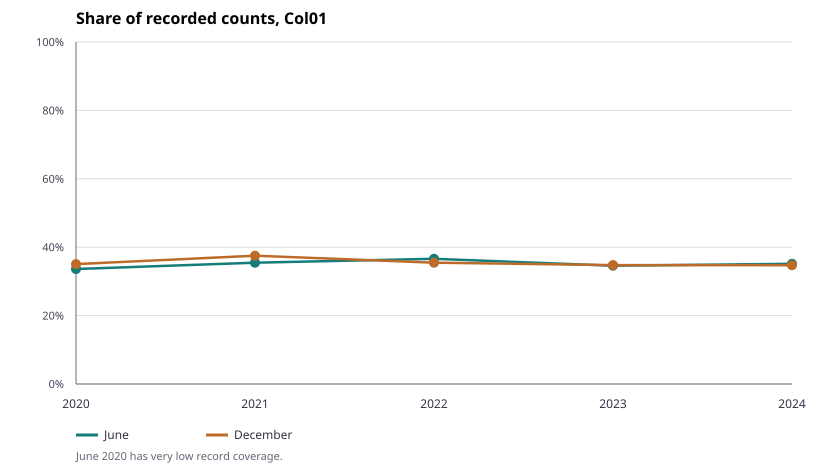

In [10]:
from IPython.display import SVG, display


def grafico_lineas_svg(tabla, columna="Matched share (%)"):
    años = sorted(tabla["Year"].dropna().astype(int).unique())
    ancho, alto = 820, 470
    izq, der, arriba, abajo = 76, 28, 42, 86
    x0, x1 = izq, ancho - der
    y0, y1 = arriba, alto - abajo
    colores = {6: "#147D79", 12: "#BD6B28"}

    def x_pos(i):
        return x0 if len(años) == 1 else x0 + i * (x1 - x0) / (len(años) - 1)
    def y_pos(valor):
        return y1 - (float(valor) / 100.0) * (y1 - y0)

    partes = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{ancho}" height="{alto}" viewBox="0 0 {ancho} {alto}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<text x="76" y="24" font-family="sans-serif" font-size="16" font-weight="600">Share of recorded counts, Col01</text>',
    ]
    for tick in (0, 20, 40, 60, 80, 100):
        y = y_pos(tick)
        partes.append(f'<line x1="{x0}" y1="{y:.1f}" x2="{x1}" y2="{y:.1f}" stroke="#d9dee5" stroke-width="1"/>')
        partes.append(f'<text x="{x0-12}" y="{y+4:.1f}" text-anchor="end" font-family="sans-serif" font-size="11" fill="#445">{tick}%</text>')
    for i, año in enumerate(años):
        x = x_pos(i)
        partes.append(f'<text x="{x:.1f}" y="{y1+24}" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#334">{año}</text>')
    partes.append(f'<line x1="{x0}" y1="{y0}" x2="{x0}" y2="{y1}" stroke="#68717d"/>')
    partes.append(f'<line x1="{x0}" y1="{y1}" x2="{x1}" y2="{y1}" stroke="#68717d"/>')

    for mes, nombre in ((6, "June"), (12, "December")):
        serie = tabla.loc[tabla["Reporting month"].eq(mes)].sort_values("Year")
        puntos = [(int(fila["Year"]), fila[columna]) for _, fila in serie.iterrows() if pd.notna(fila[columna])]
        if puntos:
            coords = " ".join(f"{x_pos(años.index(a)):.1f},{y_pos(v):.1f}" for a, v in puntos)
            partes.append(f'<polyline points="{coords}" fill="none" stroke="{colores[mes]}" stroke-width="2.5"/>')
            for a, v in puntos:
                x, y = x_pos(años.index(a)), y_pos(v)
                partes.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="5" fill="{colores[mes]}"/>')
        lx = x0 + (mes == 12) * 130
        partes.append(f'<line x1="{lx}" y1="{alto-35}" x2="{lx+22}" y2="{alto-35}" stroke="{colores[mes]}" stroke-width="3"/>')
        partes.append(f'<text x="{lx+28}" y="{alto-31}" font-family="sans-serif" font-size="12" fill="#334">{nombre}</text>')
    partes.append(f'<text x="{x0}" y="{alto-10}" font-family="sans-serif" font-size="11" fill="#667">June 2020 has very low record coverage.</text>')
    partes.append('</svg>')
    return SVG("".join(partes))

# This chart shows the complete-case reading; also review the sensitivity results.
display(grafico_lineas_svg(resumen_cortes))


## 12. Exploratory category reconciliation (2023–2024)

In 2023 and 2024, the dictionary adds P2501800 for children without a nutritional assessment due to life-course category or special condition. This section compares P2060000 Col01 with the sum of P2070501–P2070506 and P2501800 Col01. To calculate the comparison for each facility-cut, missing code rows are treated as zero **only in this sensitivity check**. A difference alone does not prove a reporting error: the rule must be confirmed in the annual DEIS manual and against the meaning of omitted rows.


In [11]:
CODIGOS_RECONCILIACION = [f"P20705{i:02d}" for i in range(1, 7)] + ["P2501800"]
filas_reconciliacion = []

for anio in (2023, 2024):
    den = tabla_codigo("P2060000", ["Col01"])
    den = den.loc[den.index.get_level_values("AnioFuente") == anio].copy()
    den_col = "P2060000__Col01"
    base = den.copy()
    status_fields = []
    for codigo in CODIGOS_RECONCILIACION:
        t = tabla_codigo(codigo, ["Col01"])
        t = t.loc[t.index.get_level_values("AnioFuente") == anio]
        base = base.join(t, how="left")
        presente = pd.Series(base.index.isin(t.index), index=base.index)
        base[f"tiene_{codigo}"] = presente
        status_fields.append(f"{codigo}__Col01")

    base = base.reset_index()
    for mes, g in base.groupby("Mes"):
        den_ok = g[den_col].notna()
        categorias = g[status_fields].copy()
        presentes = [f"tiene_{c}" for c in CODIGOS_RECONCILIACION]
        for codigo, campo in zip(CODIGOS_RECONCILIACION, status_fields):
            categorias.loc[~g[f"tiene_{codigo}"], campo] = 0
        categorias_completas = categorias.notna().all(axis=1)
        suma_categorias = categorias.sum(axis=1, min_count=len(status_fields))
        diferencia = suma_categorias - g[den_col]
        exacto = den_ok & categorias_completas & diferencia.abs().le(0.001)
        filas_reconciliacion.append({
            "Year": anio,
            "Reporting month": int(mes),
            "Units with denominator": int(den_ok.sum()),
            "Exactly reconciled": int(exacto.sum()),
            "Exact reconciliation (%)": 100 * exacto.sum() / den_ok.sum() if den_ok.sum() else np.nan,
            "Category sum minus P2060000": float(diferencia.loc[den_ok & categorias_completas].sum()),
            "Missing category rows (count)": int((~g[[f"tiene_{c}" for c in CODIGOS_RECONCILIACION]].all(axis=1) & den_ok).sum()),
        })

reconciliacion = pd.DataFrame(filas_reconciliacion).sort_values(["Year", "Reporting month"])
display(reconciliacion.round(2))


,Year,Reporting month,Units with denominator,Exactly reconciled,Exact reconciliation (%),Category sum minus P2060000,Missing category rows (count)
0,2023,6,1991,1352,67.91,-1301.0,1962
1,2023,12,2002,1446,72.23,2740.0,1973
2,2024,6,2014,1476,73.29,634.0,1979
3,2024,12,2019,1508,74.69,188.0,1962


## 13. Interpretation, scope, and limitations

- **Unit of analysis:** aggregate facility-cut-service-code record. The data cannot track individual children or establish whether the same child appears at multiple facilities or cuts.
- **Denominator:** P2060000 Col01, the population in care reported in REM-P2. The share compares categories with this administrative record, not with Chile's or a municipality's total child population.
- **Reporting cuts:** June and December appear for the selected P2 codes in each year. There is no monthly series from which to model a month-by-month trajectory.
- **Coverage:** June 2020 stands out for its low number of facilities and care counts; review it with DEIS before including it in a historical comparison.
- **Missing data:** missing code rows may mean zero or missing reporting; the tables separate the two readings. Ask for confirmation. Age/sex fields also often have blanks; the main reading does not impute them and reports availability by band.
- **Reconciliation:** comparing categories with the total is an initial diagnostic. Code P2501800 appears from 2023; do not apply that sum to earlier years. Confirm the exact manuals and rules for 2023 and 2024.
- **Classification changes:** the annual P2 sheets show stable target codes and age bands in this first review; keep each year's dictionary as the authority and revalidate before adding fields.
- **Geography:** the Serie P files include region/commune codes, but this investigation does not depend on cartography. Any geographic comparison would be descriptive, must validate the codes, and would not equal local rates without suitable population denominators.
- **Causality and significance:** this scan is descriptive; it does not identify causes or test statistical differences.

The DEIS [REM Serie P 2025–2026 manual](https://repositoriodeis.minsal.cl/ContenidoSitioWeb2020/REM/2025/SERIE/MANUAL_REM_P_2025_V1.1.pdf) may help explain the general structure, but it postdates the 2020–2024 observations. Use the manual applicable to each year to state an official reconciliation rule.


## 14. W1 rubric alignment: potential and remaining work

### Future ML use

With five years and only two cuts per year, each series has at most ten semiannual points; there is not enough data for a robust ML forecast. Coverage, missing rows, reconciliation rules, and comparability must first be confirmed. If a more granular and harmonized historical series becomes available, one could explore a forecast of recorded counts and compare it with a simple baseline using out-of-sample evaluation. The target would not be prevalence.

### Future dashboard

A monitoring dashboard could provide filters for year/cut, age, sex, facility, and possibly region; counts and recorded-share metrics; the number of matched facilities; and coverage, duplicate, and reconciliation alerts. Its title and labels should say “records in care,” not “prevalence.”

### Specific questions for the instructor

1. In these files, does a missing code row mean zero or missing reporting? Which REM-P2 manual version applies to each year?
2. Should the historical June/December comparison exclude or separately treat June 2020 because facility coverage is low?
3. Is it acceptable to present the share of P2070503 + P2070504 Col01 over P2060000 Col01 as an exploratory indicator, consistently labelled as a share of counts recorded in care, with the age/sex breakdown secondary?

### Process log (to be completed by the team)

| Required item | Team record |
|---|---|
| Scope decisions and rationale | Complete during the team meeting. |
| Checks performed, results, and changes | Reproducible notebook; record execution date and any additional exclusions. |
| Actual instructor feedback and team response | Pending; do not complete until received. |
| Each member's contribution | Complete with tasks actually performed. |
| Each member's individual reflection | Pending from each member. |
| AI use and verification | Codex assisted with the file inventory, initial dictionary comparison, and workflow construction. The team must run the notebook, compare figures with the ZIP files/dictionaries, and document any corrections before submission. |

**Before submitting W1:** include the second candidate and required comparison; verify the exact Five Cs terms from class; record sources, retrieval version/date, and reproduced results; add actual instructor feedback, contributions, and reflections.
